<a href="https://colab.research.google.com/github/hasselmanneduarda-wq/bioestat-2026/blob/main/Semin%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alunos: André Luiz Leal (Nº USP:16854274); Maria Eduarda Hasselman (Nº USP:17100517); Raissa Lara Pinheiro (Nº USP:16939302)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import glob
import os
import pandas as pd

pasta_dados = "/content/drive/MyDrive/FinalOccurrenceDataset"

arquivos_csv = [
    f for f in glob.glob(os.path.join(pasta_dados, "**", "*.csv"), recursive=True)
    if "__MACOSX" not in f
]

print(f"Total de arquivos CSV: {len(arquivos_csv)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de arquivos CSV: 365


In [ ]:
lista_dfs = [
    pd.read_csv(f, low_memory=False)
    for f in arquivos_csv
]

df = pd.concat(lista_dfs, ignore_index=True)

print(f"Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
display(df.head())

Dataset: 5013405 linhas e 16 colunas


,scientificName,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,year,month,day,depth,depthAccuracy,basisOfRecord,issue,source,Unnamed: 0,coordinate,depthAccur,basisOfRec
0,Coelorinchus marinii,-37.400000,-54.933000,NaN,1961.0,12.0,NaN,NaN,NaN,PRESERVED_SPECIMEN,GEODETIC_DATUM_ASSUMED_WGS84;TAXON_MATCH_HIGHE...,GBIF,NaN,NaN,NaN,NaN
1,Coelorinchus marinii,-37.400002,-54.932999,NaN,NaN,NaN,NaN,NaN,NaN,PreservedSpecimen,NaN,OBIS,NaN,NaN,NaN,NaN
2,Coelorinchus marinii,-37.400002,-54.933334,NaN,NaN,NaN,NaN,NaN,NaN,PreservedSpecimen,NaN,OBIS,NaN,NaN,NaN,NaN
3,Coelorinchus marinii,-26.006667,-46.378450,NaN,2002.0,2.0,27.0,150.0,NaN,PreservedSpecimen,NaN,OBIS,NaN,NaN,NaN,NaN
4,Coelorinchus marinii,-34.558667,-51.919000,NaN,2002.0,3.0,24.0,172.0,NaN,PreservedSpecimen,NaN,OBIS,NaN,NaN,NaN,NaN


In [ ]:
df.columns = df.columns.str.strip()

df_limpo = df.dropna(
    subset=["depth", "scientificName", "decimalLatitude", "decimalLongitude"]
).copy()

for coluna in ["depth", "decimalLatitude", "decimalLongitude"]:
    df_limpo[coluna] = pd.to_numeric(df_limpo[coluna], errors="coerce")

df_limpo = df_limpo.dropna(
    subset=["depth", "decimalLatitude", "decimalLongitude"]
)

df_limpo = df_limpo[
    df_limpo["depth"].between(0, 11000) &
    df_limpo["decimalLatitude"].between(-90, 90) &
    df_limpo["decimalLongitude"].between(-180, 180)
].drop_duplicates()

print(f"Registros válidos: {len(df_limpo)}")

Registros válidos: 1392273


In [ ]:
df_pre_brasil = df_limpo[
    df_limpo["decimalLatitude"].between(-36, 7) &
    df_limpo["decimalLongitude"].between(-56, -24)
].copy()

print(f"Registros no pré-recorte: {len(df_pre_brasil)}")

Registros no pré-recorte: 9630


In [ ]:
!pip install geopandas pyogrio -q

import geopandas as gpd
import requests

url_base = (
    "https://pamgia.ibama.gov.br/server/rest/services/"
    "01_Publicacoes_Bases/lim_amazonia_azul/FeatureServer"
)

def carregar_camada(numero):
    resposta = requests.get(
        f"{url_base}/{numero}/query",
        params={
            "where": "1=1",
            "outFields": "*",
            "returnGeometry": "true",
            "outSR": "4326",
            "f": "geojson"
        },
        headers={"User-Agent": "Mozilla/5.0"},
        timeout=60
    )

    resposta.raise_for_status()

    return gpd.GeoDataFrame.from_features(
        resposta.json()["features"],
        crs="EPSG:4326"
    )

mar_territorial = carregar_camada(0)
zee = carregar_camada(2)

print("Mar Territorial e ZEE carregados!")

Mar Territorial e ZEE carregados!


In [ ]:
area_brasil = gpd.GeoDataFrame(
    pd.concat([
        mar_territorial[["geometry"]],
        zee[["geometry"]]
    ], ignore_index=True),
    crs="EPSG:4326"
)

pontos = gpd.GeoDataFrame(
    df_pre_brasil,
    geometry=gpd.points_from_xy(
        df_pre_brasil["decimalLongitude"],
        df_pre_brasil["decimalLatitude"]
    ),
    crs="EPSG:4326"
)

pontos_brasil = gpd.sjoin(
    pontos, area_brasil,
    how="inner",
    predicate="within"
)

df_brasil = pd.DataFrame(
    pontos_brasil.drop(columns=["geometry", "index_right"], errors="ignore")
).copy()

print(f"Registros brasileiros: {len(df_brasil)}")
print(f"Espécies: {df_brasil['scientificName'].nunique()}")

Registros brasileiros: 3893
Espécies: 97


Após a remoção de registros incompletos, duplicatas ou com coordenadas e profundidades inválidas, a base de dados foi limitada ao Mar Territorial e à Zona Econômica Exclusiva (ZEE) brasileira. O processo resultou em 3.893 registros de ocorrência de 97 espécies distintas de peixes.A análise de distribuição revelou que a maior parte das coletas se concentra em regiões costeiras e rasas, diminuindo drasticamente com o aumento da profundidade. Além disso, a maioria dos pontos analisados apresenta riqueza moderada de espécies, enquanto a biodiversidade muito alta se restringe a poucas regiões específicas.

In [ ]:
import numpy as np

df_brasil["inicio_faixa"] = (
    np.floor(df_brasil["depth"] / 100) * 100
).astype(int)

df_brasil["faixa_100m"] = (
    df_brasil["inicio_faixa"].astype(str) + "–" +
    (df_brasil["inicio_faixa"] + 100).astype(str)
)

df_riqueza = (
    df_brasil
    .groupby(["inicio_faixa", "faixa_100m"])["scientificName"]
    .nunique()
    .reset_index(name="riqueza")
)

display(df_riqueza.head(10))

,inicio_faixa,faixa_100m,riqueza
0,0,0–100,43
1,100,100–200,35
2,200,200–300,29
3,300,300–400,27
4,400,400–500,31
5,500,500–600,26
6,600,600–700,22
7,700,700–800,10
8,800,800–900,9
9,900,900–1000,8


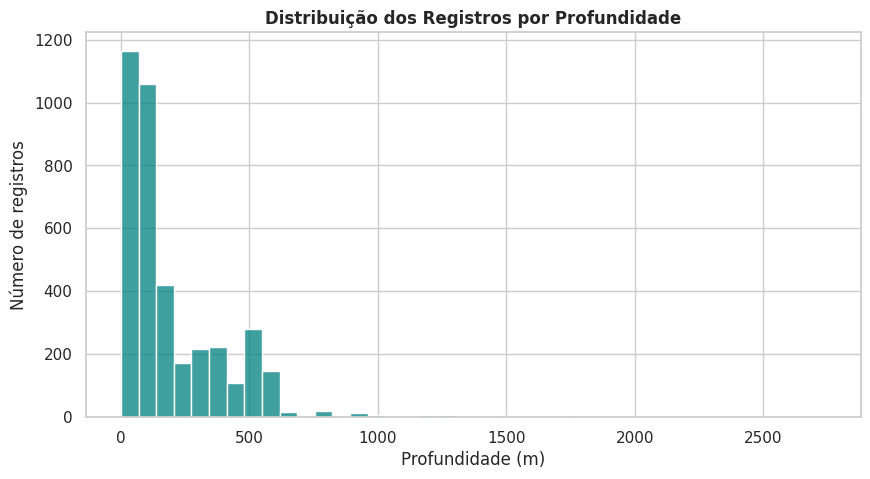

Q1: 60.0
Mediana: 120.0
Q3: 300.0
Máxima: 2743.0


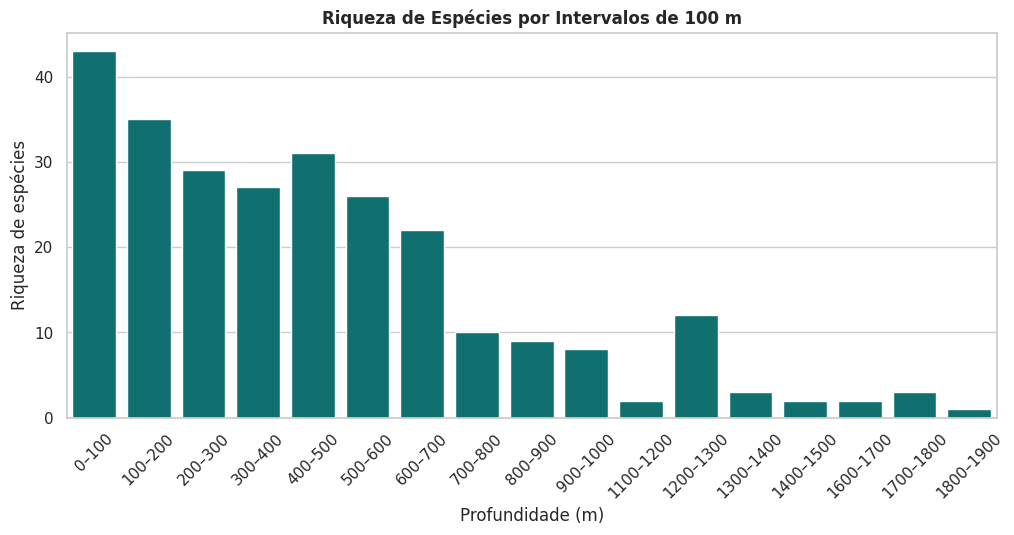

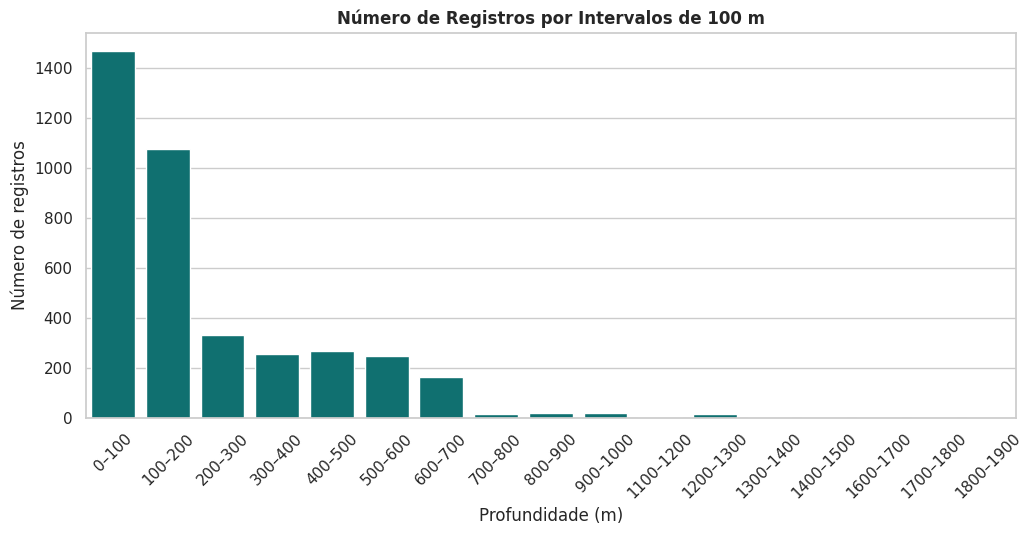

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for np.floor

sns.set_theme(style="whitegrid")

# Re-create 'inicio_faixa' and 'faixa_100m' columns in df_brasil
# This is necessary because df_brasil was reset by a re-execution of a previous cell (2mv7Gm0DAFe7)
# after these columns were initially added in cell 2wVlait1AJHx.
df_brasil["inicio_faixa"] = (
    np.floor(df_brasil["depth"] / 100) * 100
).astype(int)

df_brasil["faixa_100m"] = (
    df_brasil["inicio_faixa"].astype(str) + "–" +
    (df_brasil["inicio_faixa"] + 100).astype(str)
)


# SLIDE 5
plt.figure(figsize=(10, 5))
sns.histplot(data=df_brasil, x="depth", bins=40, color="teal")
plt.title("Distribuição dos Registros por Profundidade", fontweight="bold")
plt.xlabel("Profundidade (m)")
plt.ylabel("Número de registros")
plt.show()
print("Q1:", df_brasil["depth"].quantile(0.25))
print("Mediana:", df_brasil["depth"].median())
print("Q3:", df_brasil["depth"].quantile(0.75))
print("Máxima:", df_brasil["depth"].max())

# SLIDE 6
dados_slide = df_riqueza[df_riqueza["inicio_faixa"] < 2000]

plt.figure(figsize=(12, 5))
sns.barplot(data=dados_slide, x="faixa_100m", y="riqueza", color="teal")
plt.title("Riqueza de Espécies por Intervalos de 100 m", fontweight="bold")
plt.xlabel("Profundidade (m)")
plt.ylabel("Riqueza de espécies")
plt.xticks(rotation=45)
plt.show()

# SLIDE 7
df_registros = (
    df_brasil
    .groupby(["inicio_faixa", "faixa_100m"])
    .size()
    .reset_index(name="registros")
)

dados_registros = df_registros[df_registros["inicio_faixa"] < 2000]

plt.figure(figsize=(12, 5))
sns.barplot(data=dados_registros, x="faixa_100m", y="registros", color="teal")
plt.title("Número de Registros por Intervalos de 100 m", fontweight="bold")
plt.xlabel("Profundidade (m)")
plt.ylabel("Número de registros")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from scipy import stats

r, p_pearson = stats.pearsonr(
    df_riqueza["inicio_faixa"],
    df_riqueza["riqueza"]
)

rho, p_spearman = stats.spearmanr(
    df_riqueza["inicio_faixa"],
    df_riqueza["riqueza"]
)

print(f"Pearson: r = {r:.3f} | p = {p_pearson:.4e}")
print(f"Spearman: ρ = {rho:.3f} | p = {p_spearman:.4e}")

Pearson: r = -0.859 | p = 2.5486e-06
Spearman: ρ = -0.939 | p = 2.5973e-09


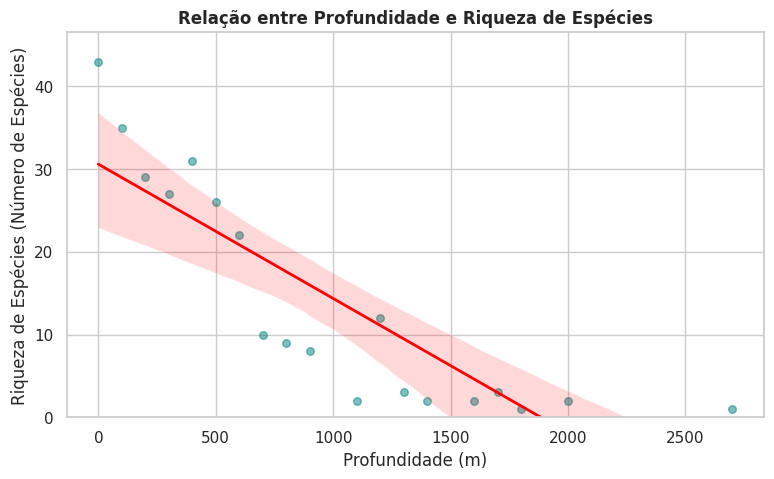

In [ ]:
plt.figure(figsize=(9, 5))

sns.regplot(
    data=df_riqueza,
    x="inicio_faixa",
    y="riqueza",
    color="teal",
    scatter_kws={"alpha": 0.5, "s": 30},
    line_kws={"color": "red", "linewidth": 2},
)

plt.title(
    "Relação entre Profundidade e Riqueza de Espécies",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Profundidade (m)")
plt.ylabel("Riqueza de Espécies (Número de Espécies)")

# Impede que o eixo Y mostre valores negativos
plt.ylim(bottom=0)

plt.show()

Ao cruzar a profundidade com a riqueza de espécies registrada em cada intervalo de 100 m, observou-se uma tendência de redução da riqueza com o aumento da profundidade. Essa relação é visualizada no gráfico de dispersão pela inclinação negativa da linha de tendência e também pelos valores negativos das correlações de Pearson e Spearman. Entretanto, como o número de registros também varia entre as faixas de profundidade, essa relação deve ser interpretada como uma associação observada no conjunto de dados, e não como uma relação direta de causa e efeito.

,Especie,Ocorrencias
0,Merluccius hubbsi,545
1,Trichiurus lepturus,511
2,Urophycis brasiliensis,402
3,Thyrsites lepidopodea,295
4,Thunnus albacares,245
5,Urophycis mystacea,190
6,Bregmaceros atlanticus,153
7,Ariomma bondi,151
8,Urophycis cirrata,132
9,Thunnus obesus,114


/tmp/ipykernel_980/2891351927.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


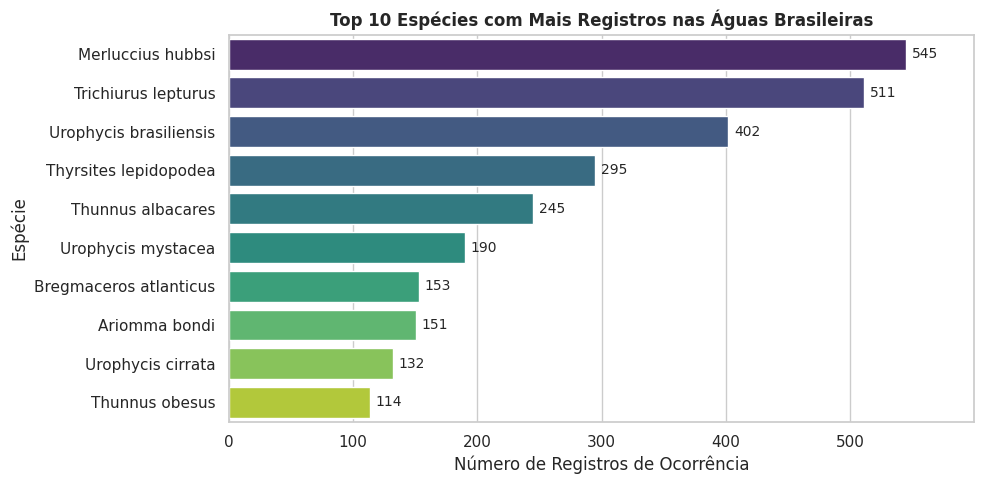

In [ ]:
# TOP 10 ESPÉCIES COM MAIS REGISTROS

top_especies = (
    df_brasil["scientificName"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_especies.columns = ["Especie", "Ocorrencias"]

# Mostrar os valores exatos em tabela
display(top_especies)


# Criar o gráfico
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=top_especies,
    y="Especie",
    x="Ocorrencias",
    palette="viridis"
)

# Adicionar o valor exato ao final de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        fontsize=10
    )

plt.title(
    "Top 10 Espécies com Mais Registros nas Águas Brasileiras",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Número de Registros de Ocorrência")
plt.ylabel("Espécie")

# Dar espaço para os números no final das barras
plt.xlim(
    0,
    top_especies["Ocorrencias"].max() * 1.10
)

plt.tight_layout()
plt.show()

O gráfico com as dez espécies mais frequentes no registro de ocorrência. Isso mostra que o banco de dados é dominado por um grupo pequeno de peixes. Poucas espécies acumulam a grande maioria dos registros de ocorrência. Isso indica que esses peixes mais comuns são muito abundantes na região ou possuem uma capacidade maior de se adaptar a diferentes áreas. Por outro lado, também reflete um padrão comum em pesquisas de campo, onde as espécies mais fáceis de capturar em locais rasos acabam sendo registradas com mais frequência.
